In [ ]:
from __future__ import annotations
from gwpopulation.models.redshift import PowerLawRedshift
from bilby.core.result import read_in_result
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt
import h5py
from typing import Tuple, Dict, List, Mapping

# Parameter generation

In [ ]:
import mc_pipeline.monte_carlo_pipeline as monte_carlo_pipeline

In [4]:
m1_test, m_ratio_test = monte_carlo_pipeline.sample_from_2D_ppd("analyses/PowerLawPeak/o1o2o3_mass_c_iid_mag_iid_tilt_powerlaw_redshift_mass_data.h5", 100000, (2.0, 100.0), (0.1, 1.0))
a1_test, a2_test = monte_carlo_pipeline.sample_from_2D_ppd("analyses/PowerLawPeak/o1o2o3_mass_c_iid_mag_iid_tilt_powerlaw_redshift_magnitude_data.h5", 100000, (0.0, 1.0), (0.0, 1.0))

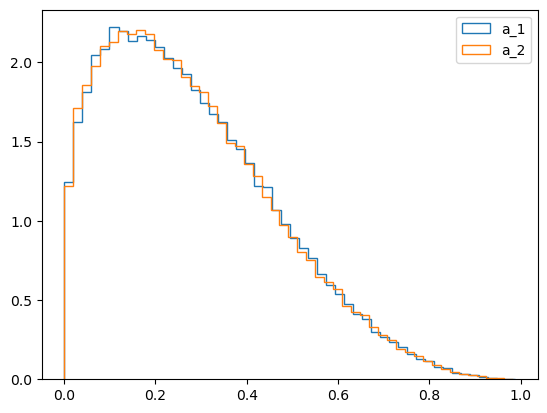

In [6]:
plt.hist(a1_test, bins=50, density=True, histtype='step', label="a_1")
plt.hist(a2_test, bins=50, density=True, histtype='step', label="a_2")
plt.legend()

Text(0.5, 0, 'm_1')

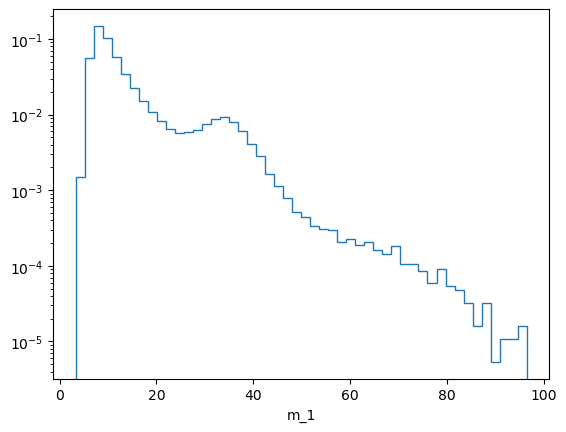

In [13]:
plt.hist(m1_test, bins=50, density=True, histtype='step', log=True)
plt.xlabel("m_1")

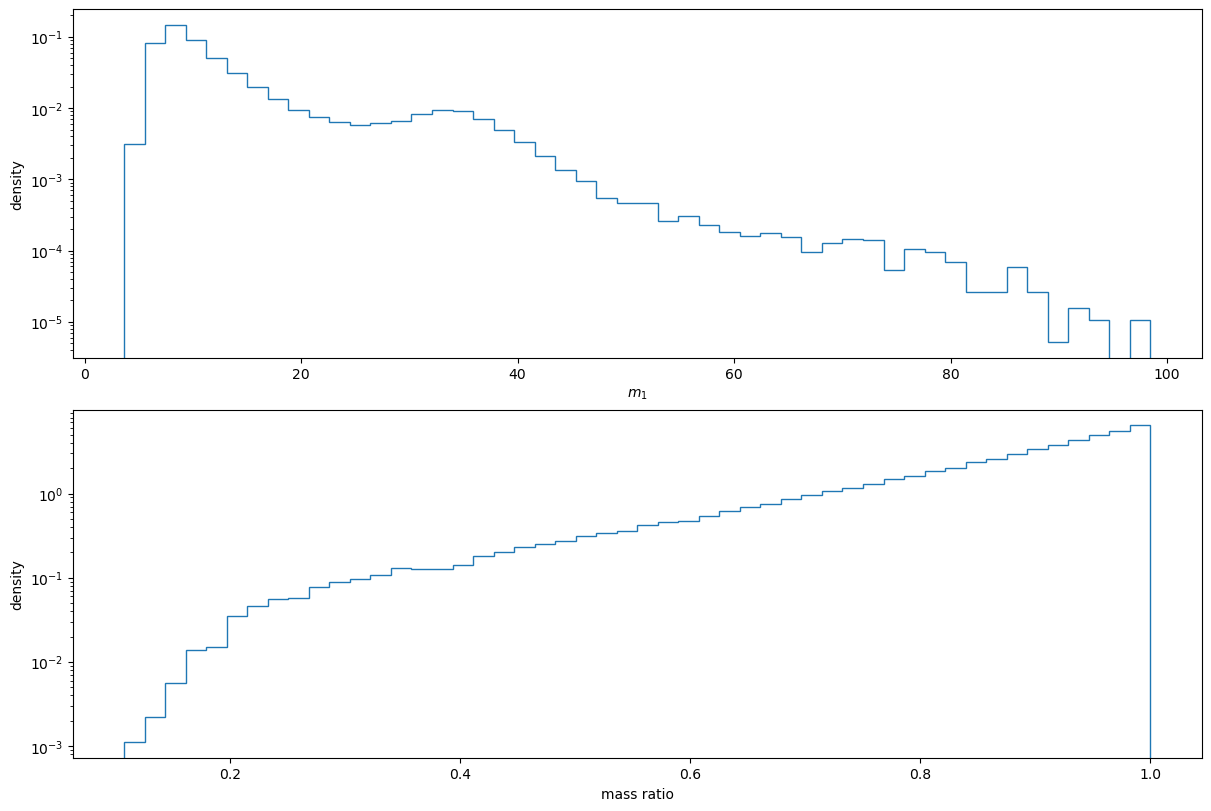

In [5]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=False,
    constrained_layout=True
)

# Top: m1
axes[0].hist(m1_test, bins=50, density=True, histtype="step", log=True)
axes[0].set_xlabel(r"$m_1$")
axes[0].set_ylabel("density")
axes[0].set_yscale("log")

# Bottom: mass ratio
axes[1].hist(m_ratio_test, bins=50, density=True, histtype="step", log=True)
axes[1].set_xlabel("mass ratio")
axes[1].set_ylabel("density")
axes[1].set_yscale("log")

plt.show()


Text(0.5, 0, 'm_1')

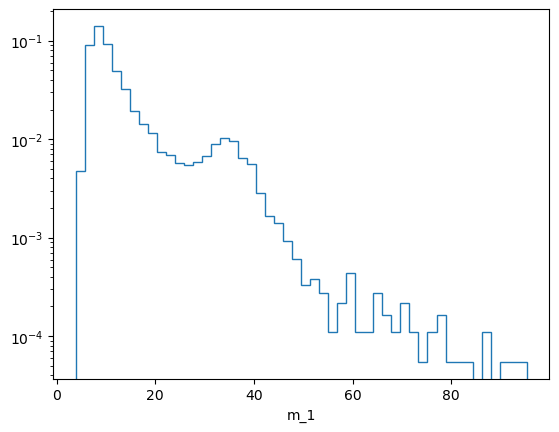

In [33]:
plt.hist(m1_test, bins=50, density=True, histtype='step', log=True)
plt.xlabel("m_1")

In [38]:
from __future__ import annotations

from typing import Iterable
import h5py


def probe_h5(path: str, max_depth: int = 4) -> None:
    """Print group/dataset structure with shapes and a few attributes."""
    def _recurse(obj: h5py.Group, prefix: str, depth: int) -> None:
        if depth > max_depth:
            return
        for k in obj.keys():
            item = obj[k]
            p = f"{prefix}/{k}"
            if isinstance(item, h5py.Dataset):
                attrs = {ak: item.attrs[ak] for ak in list(item.attrs.keys())[:8]}
                print(f"{p}  DATASET shape={item.shape} dtype={item.dtype} attrs={attrs}")
            else:
                attrs = {ak: item.attrs[ak] for ak in list(item.attrs.keys())[:8]}
                print(f"{p}  GROUP keys={len(item.keys())} attrs={attrs}")
                _recurse(item, p, depth + 1)

    with h5py.File(path, "r") as f:
        print("FILE:", path)
        print("TOP LEVEL KEYS:", list(f.keys()))
        _recurse(f, "", 1)


mag_file = "analyses/PowerLawPeak/o1o2o3_mass_c_iid_mag_iid_tilt_powerlaw_redshift_magnitude_data.h5"
probe_h5(mag_file, max_depth=5)

# Additionally, focus on the specific groups you care about
with h5py.File(mag_file, "r") as f:
    for var in ["a_1", "a_2"]:
        print(f"\n--- lines/{var} ---")
        obj = f["lines"][var]
        print("type:", type(obj))
        print("keys (if group):", list(obj.keys()) if isinstance(obj, h5py.Group) else None)
        if isinstance(obj, h5py.Dataset):
            print("shape:", obj.shape, "dtype:", obj.dtype)
            print("attrs:", dict(obj.attrs))

    print("\n--- ppd ---")
    ppd = f["ppd"]
    print("ppd type:", type(ppd))
    if isinstance(ppd, h5py.Dataset):
        print("ppd shape:", ppd.shape, "dtype:", ppd.dtype)
        print("ppd attrs:", dict(ppd.attrs))
    else:
        print("ppd keys:", list(ppd.keys())[:50])

FILE: analyses/PowerLawPeak/o1o2o3_mass_c_iid_mag_iid_tilt_powerlaw_redshift_magnitude_data.h5
TOP LEVEL KEYS: ['lines', 'ppd']
/lines  GROUP keys=2 attrs={'CLASS': np.bytes_(b'GROUP'), 'TITLE': np.bytes_(b'dict:2'), 'VERSION': np.bytes_(b'1.0')}
/lines/a_1  DATASET shape=(10000, 1000) dtype=float64 attrs={'CLASS': np.bytes_(b'CARRAY'), 'TITLE': Empty(dtype=dtype('S1')), 'VERSION': np.bytes_(b'1.1')}
/lines/a_2  DATASET shape=(10000, 1000) dtype=float64 attrs={'CLASS': np.bytes_(b'CARRAY'), 'TITLE': Empty(dtype=dtype('S1')), 'VERSION': np.bytes_(b'1.1')}
/ppd  DATASET shape=(1000, 1000) dtype=float64 attrs={'CLASS': np.bytes_(b'CARRAY'), 'TITLE': Empty(dtype=dtype('S1')), 'VERSION': np.bytes_(b'1.1')}

--- lines/a_1 ---
type: <class 'h5py._hl.dataset.Dataset'>
keys (if group): None
shape: (10000, 1000) dtype: float64
attrs: {'CLASS': np.bytes_(b'CARRAY'), 'TITLE': Empty(dtype=dtype('S1')), 'VERSION': np.bytes_(b'1.1')}

--- lines/a_2 ---
type: <class 'h5py._hl.dataset.Dataset'>
keys (i

In [ ]:
m1_test, m_ratio_test = monte_carlo_pipeline.sample_from_2D_ppd("analyses/PowerLawPeak/o1o2o3_mass_c_iid_mag_iid_tilt_powerlaw_redshift_mass_data.h5", 1, (2.0, 100.0), (0.1, 1.0))
a1_test, a2_test = monte_carlo_pipeline.sample_from_2D_ppd("analyses/PowerLawPeak/o1o2o3_mass_c_iid_mag_iid_tilt_powerlaw_redshift_magnitude_data.h5", 1, (0.0, 1.0), (0.0, 1.0))

In [9]:
m1_test, m_ratio_test, a1_test, a2_test

(array([10.47805113]),
 array([0.74798439]),
 array([0.16095963]),
 array([0.2216512]))

# Smoke test

In [ ]:
import bilby
import numpy as np
from bilby.gw.detector import InterferometerList
from bilby.gw.waveform_generator import WaveformGenerator
from bilby.gw.likelihood import GravitationalWaveTransient
from bilby.gw.prior import BBHPriorDict
from mc_pipeline.monte_carlo_pipeline import generate_injection_catalog
from typing import Tuple, Dict, List, Mapping

In [2]:
mass_ppd_path = "analyses/PowerLawPeak/o1o2o3_mass_c_iid_mag_iid_tilt_powerlaw_redshift_mass_data.h5"
spin_ppd_path = "analyses/PowerLawPeak/o1o2o3_mass_c_iid_mag_iid_tilt_powerlaw_redshift_magnitude_data.h5"
lambda_path = "analyses/PowerLawPeak/o1o2o3_mass_c_iid_mag_iid_tilt_powerlaw_redshift_result.json"

we need this below to reject quiet events

In [3]:
def make_snr_context(
    duration: float = 8.0,
    fs: float = 2048.0,
    fmin: float = 20.0,
    approximant: str = "IMRPhenomPv2",
    detectors: tuple[str, ...] = ("H1", "L1", "V1"),
):
    ifos = InterferometerList(list(detectors))
    # This sets up the frequency array + PSD arrays (start_time is irrelevant for optimal SNR)
    ifos.set_strain_data_from_power_spectral_densities(
        sampling_frequency=fs,
        duration=duration,
        start_time=0.0,
    )

    wfg = WaveformGenerator(
        duration=duration,
        sampling_frequency=fs,
        frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
        waveform_arguments=dict(
            waveform_approximant=approximant,
            reference_frequency=50.0,
            minimum_frequency=fmin,
        ),
    )
    return ifos, wfg


def network_optimal_snr(inj: dict, ifos: InterferometerList, wfg: WaveformGenerator) -> float:
    polarizations = wfg.frequency_domain_strain(parameters=inj)

    snr2 = 0.0
    for ifo in ifos:
        signal = ifo.get_detector_response(polarizations=polarizations, parameters=inj)
        snr2 += float(ifo.optimal_snr_squared(signal))
    return float(np.sqrt(snr2))


In [4]:
rng = np.random.default_rng(0)

injections, lamb = generate_injection_catalog( # type: ignore
    n_events=10,
    mass_ppd_path=mass_ppd_path,
    spin_ppd_path=spin_ppd_path,
    bilby_result_path_for_lambda=lambda_path,
    rng=rng,
)

In [ ]:
def check_snrs(
    inj: Mapping[str, float],
    duration: float = 8.0,
    fs: float = 2048.0,
    fmin: float = 20.0,
    waveform_approximant: str = "IMRPhenomPv2",
    zero_noise: bool = True,
):
	for k in ("geocent_time", "mass_1", "mass_2", "luminosity_distance"):
		if k not in inj:
			raise KeyError(f"inj is missing required key '{k}'")

	# 1) detectors + data
	ifos = InterferometerList(["H1", "L1", "V1"])
	start_time = int(inj["geocent_time"] - duration / 2.0)

	if zero_noise:
		ifos.set_strain_data_from_zero_noise(
			sampling_frequency=fs,
			duration=duration,
			start_time=start_time,
		)
	else:
		ifos.set_strain_data_from_power_spectral_densities(
			sampling_frequency=fs,
			duration=duration,
			start_time=start_time,
		)

	# 2) waveform generator
	wfg = WaveformGenerator(
		duration=duration,
		sampling_frequency=fs,
		frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
		waveform_arguments=dict(
			waveform_approximant=waveform_approximant,
			reference_frequency=50.0,
			minimum_frequency=fmin,
		),
	)

	# 3) inject
	ifos.inject_signal(waveform_generator=wfg, parameters=dict(inj))
	net_snr = float(np.sqrt(sum(ifo.meta_data["optimal_SNR"]**2 for ifo in ifos)))
	return net_snr

In [8]:
snrs = []
for i in range(10):
	snrs.append(check_snrs(injections[i]))

16:44 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=8.0, sampling_frequency=2048.0, start_time=0, frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole, time_domain_source_model=None, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters, waveform_arguments={'waveform_approximant': 'IMRPhenomPv2', 'reference_frequency': 50.0, 'minimum_frequency': 20.0})
16:44 bilby INFO    : Injected signal in H1:
16:44 bilby INFO    :   optimal SNR = 0.58
16:44 bilby INFO    :   matched filter SNR = 0.58-0.00j
16:44 bilby INFO    :   mass_1 = 16.37086709001614
16:44 bilby INFO    :   mass_2 = 16.27997868238907
16:44 bilby INFO    :   a_1 = 0.2571343807053819
16:44 bilby INFO    :   a_2 = 0.30878836828966033
16:44 bilby INFO    :   tilt_1 = 3.036883463505725
16:44 bilby INFO    :   tilt_2 = 0.7744460199237571
16:44 bilby INFO    :   phi_12 = 0.21102439329246717
16:44 bilby INFO    :   phi_jl = 4.584560380312186
16:44 bilby INFO 

In [9]:
snrs

[1.1136163276922486,
 7.315305685497233,
 3.0515477058498783,
 0.7602819157174099,
 2.3522871212530987,
 1.8068004041791959,
 2.3850614833381307,
 1.439356542278115,
 1.6602785675377232,
 2.408287433659862]

In [7]:
def run_one_event_pe(
    inj: Mapping[str, float],
    duration: float = 8.0,
    fs: float = 2048.0,
    fmin: float = 20.0,
    outdir: str = "pe_out",
    label: str = "event",
    waveform_approximant: str = "IMRPhenomPv2",
    nlive: int = 300,
    dlogz: float = 10.0,
    walks: int = 20,
    time_window: float = 0.05,
    mass_window: float = 3.0,
    distance_window: tuple[float, float] = (0.5, 2.0),
    fix_sky: bool = True,
    fix_spins_and_orientation: bool = True,
    zero_noise: bool = True,
):
	"""
	Run a fast-but-more-realistic Bilby PE for a single injected event.

	This is intended as a "stage 2" validation run:
		- still low-dimensional (typically sampling only m1,m2)
		- but uses Bilby's marginalizations over time, phase, and distance

	The function:
		1) Builds detector data (zero-noise or PSD noise)
		2) Injects the signal described by `inj`
		3) Sets priors centered near the injection for fast convergence
		4) Runs dynesty with time/phase/distance marginalization enabled

	Args:
		inj (Mapping[str, float]): Bilby-compatible injection dictionary. Must include
			at least 'geocent_time', 'mass_1', 'mass_2', 'ra', 'dec', 'psi',
			'theta_jn', spins, and 'luminosity_distance'.
		duration (float): Data segment duration (s).
		fs (float): Sampling frequency (Hz).
		fmin (float): Minimum frequency for waveform generation (Hz).
		outdir (str): Output directory for Bilby results.
		label (str): Label for output files.
		waveform_approximant (str): LAL waveform approximant name (e.g. 'IMRPhenomPv2',
			'IMRPhenomXPHM' if you can afford it).
		nlive (int): Dynesty live points (lower = faster, less accurate).
		dlogz (float): Dynesty stopping criterion (higher = faster, less accurate).
		walks (int): Dynesty random-walk length.
		time_window (float): Half-width of geocent_time Uniform prior around injection (s).
		mass_window (float): Half-width of Uniform priors for mass_1 and mass_2 around injection (Msun).
		distance_window (tuple[float, float]): Multiplicative bounds (low, high) for
			luminosity_distance prior relative to injected distance (e.g. (0.5, 2.0)).
		fix_sky (bool): If True, set ra/dec/psi priors to DeltaFunctions at injected values.
		fix_spins_and_orientation (bool): If True, set spins and theta_jn to DeltaFunctions.
		zero_noise (bool): If True, use zero-noise strain; if False, draw Gaussian noise from PSD.

	Returns:
		bilby.core.result.Result: Bilby result object; posterior samples are in result.posterior.
	"""
	for k in ("geocent_time", "mass_1", "mass_2", "luminosity_distance"):
		if k not in inj:
			raise KeyError(f"inj is missing required key '{k}'")

	# 1) detectors + data
	ifos = InterferometerList(["H1", "L1", "V1"])
	start_time = int(inj["geocent_time"] - duration / 2.0)

	if zero_noise:
		ifos.set_strain_data_from_zero_noise(
			sampling_frequency=fs,
			duration=duration,
			start_time=start_time,
		)
	else:
		ifos.set_strain_data_from_power_spectral_densities(
			sampling_frequency=fs,
			duration=duration,
			start_time=start_time,
		)

	# 2) waveform generator
	wfg = WaveformGenerator(
		duration=duration,
		sampling_frequency=fs,
		frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
		waveform_arguments=dict(
			waveform_approximant=waveform_approximant,
			reference_frequency=50.0,
			minimum_frequency=fmin,
		),
	)

	# 3) inject
	ifos.inject_signal(waveform_generator=wfg, parameters=dict(inj))
	net_snr = float(np.sqrt(sum(ifo.meta_data["optimal_SNR"]**2 for ifo in ifos)))
	if net_snr < 5:
		print(f"net snr too low ({net_snr}); skipping event")
		return

	# 4) priors (m1,m2 parameterization + marginalizations)
	priors = BBHPriorDict()

	# IMPORTANT: avoid redundant mass parameterizations
	priors.pop("chirp_mass", None)
	priors.pop("mass_ratio", None)

	m1 = float(inj["mass_1"])
	m2 = float(inj["mass_2"])
	dm = float(mass_window)

	priors["mass_1"] = bilby.core.prior.Uniform(m1 - dm, m1 + dm, name="mass_1")

	# keep m2 < m1 by a small margin to avoid invalid proposals
	m2_min = m2 - dm
	m2_max = min(m2 + dm, m1 - 0.5)
	if m2_max <= m2_min:
		raise ValueError(f"Invalid mass windows lead to empty mass_2 range: [{m2_min}, {m2_max}]")
	priors["mass_2"] = bilby.core.prior.Uniform(m2_min, m2_max, name="mass_2")

	# geocent_time prior required for time marginalization
	t0 = float(inj["geocent_time"])
	priors["geocent_time"] = bilby.core.prior.Uniform(t0 - time_window, t0 + time_window, name="geocent_time")

	# distance prior required for distance marginalization; keep it reasonably tight for speed
	dL = float(inj["luminosity_distance"])
	lo, hi = distance_window
	priors["luminosity_distance"] = bilby.core.prior.Uniform(lo * dL, hi * dL, name="luminosity_distance")

	# do NOT DeltaFunction phase or luminosity_distance if you're marginalizing them
	# phase prior is left as provided by BBHPriorDict()

	if fix_sky:
		for k in ("ra", "dec", "psi"):
			if k not in inj:
				raise KeyError(f"inj is missing required sky key '{k}'")
		priors["ra"] = bilby.core.prior.DeltaFunction(float(inj["ra"]))
		priors["dec"] = bilby.core.prior.DeltaFunction(float(inj["dec"]))
		priors["psi"] = bilby.core.prior.DeltaFunction(float(inj["psi"]))

	if fix_spins_and_orientation:
		for k in ("theta_jn", "a_1", "a_2", "tilt_1", "tilt_2", "phi_12", "phi_jl"):
			if k not in inj:
				raise KeyError(f"inj is missing required spin/orientation key '{k}'")
			priors[k] = bilby.core.prior.DeltaFunction(float(inj[k]))

	# 5) likelihood (marginalizations enabled)
	likelihood = GravitationalWaveTransient(
		interferometers=ifos,
		waveform_generator=wfg,
		priors=priors,
		time_marginalization=True,
		phase_marginalization=True,
		distance_marginalization=True,
	)

	# 6) sample
	result = bilby.run_sampler(
		likelihood=likelihood,
		priors=priors,
		sampler="dynesty",
		nlive=nlive,
		dlogz=dlogz,
		walks=walks,
		outdir=outdir,
		label=label,
		clean=True,
	)

	return result

In [8]:
run_one_event_pe(injections[0], label=f"event_rng_0")

16:38 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=8.0, sampling_frequency=2048.0, start_time=0, frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole, time_domain_source_model=None, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters, waveform_arguments={'waveform_approximant': 'IMRPhenomPv2', 'reference_frequency': 50.0, 'minimum_frequency': 20.0})
/global/homes/c/clwelch/.conda/envs/BHsuper/lib/python3.11/site-packages/lalsimulation/lalsimulation.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress t

net snr too low (2.9254803195520607); skipping event


In [14]:
result = bilby.result.read_in_result(outdir="pe_out", label="event")

In [15]:
print("search params:", result.search_parameter_keys)


search params: ['mass_1', 'mass_2', 'time_jitter']


# Sanity check post-refactor

In [ ]:
from mc_pipeline.monte_carlo_pipeline import generate_injection_catalog
import numpy as np

rng = np.random.default_rng(0)

mass_ppd_path = "analyses/PowerLawPeak/o1o2o3_mass_c_iid_mag_iid_tilt_powerlaw_redshift_mass_data.h5"
spin_ppd_path = "analyses/PowerLawPeak/o1o2o3_mass_c_iid_mag_iid_tilt_powerlaw_redshift_magnitude_data.h5"
lambda_path = "analyses/PowerLawPeak/o3only_mass_c_iid_mag_iid_tilt_powerlaw_redshift_result.json"

injections, lamb = generate_injection_catalog(
    n_events=1,
    mass_ppd_path=mass_ppd_path,
    spin_ppd_path=spin_ppd_path,
    bilby_result_path_for_lambda=lambda_path,
    rng=rng
)

inj = injections[0]

In [16]:
inj

{'mass_1': 33.93715715177294,
 'mass_2': 30.27252434276284,
 'a_1': 0.012544240345419634,
 'a_2': 0.08911939300815362,
 'tilt_1': 2.2412726013682147,
 'tilt_2': 2.2671403973687902,
 'phi_12': 2.1984189356527435,
 'phi_jl': 1.448533373272563,
 'luminosity_distance': 15702.46087508721,
 'ra': 4.212534840251065,
 'dec': np.float64(-0.8785923593495513),
 'theta_jn': np.float64(0.6557042232128958),
 'psi': 2.695896440327424,
 'phase': 0.017762767097894937,
 'geocent_time': 1126259462.4}